# Классификация заемщиков линейными моделями

## курс "Машинное обучение 1", программа AIMasters, 2025

## Студент: Гореленкова Анастасия Петровна

## Реализация алгоритмов (5 баллов)

Ниже нужно написать собственную реализацию линейного классификатора с произвольной функцией потерь и реализацию функции и градиента функции потерь для логистической регрессии.

Реализации можно частично проверить через юнит тесты.

В этом блоке можно использовать только `numpy, scipy`.


В `BinaryLogisticLoss` вам нужно реализовать расчет лосса и его градиента для функции
$$L(w) = \frac{1}{N} \sum_{N} [\log(1 + \exp(-y_i\langle w, x_i\rangle))] + \lambda \lVert w \rVert^2_2, \quad y \in \{-1, 1\}$$
$$L'(w) = \frac{1}{N} \sum_{i=1}^{N} {-y_i x_i \frac{\exp(-y_i\langle w, x_i\rangle)}{1 + \exp(-y_i\langle w, x_i\rangle)}}$$

- `func(self, X, y, w)` — вычисление значения функции потерь на матрице признаков X, векторе ответов y с вектором весов w.
- `grad(self, X, y, w)` — вычисление значения градиента функции потерь на матрице признаков X, векторе ответов y с вектором весов w.

У обоих методов одинаковые аргументы:
- X - выборка объектов
- y - вектор ответов
- w - вектор коэффициентов модели

Вектор коэффициентов имеет вид: w = `[bias, weights]`, то есть нулевой элемент w - `bias`, остальное - веса, участвующие в скалярном произведении. **Важно:** `bias` не участвует в расчете слагаемого с $\lambda$.

Обратите внимание, что на матрица X на входе без столбца с 1 в начале. Пример изменения Х внутри кода функций:
```python
X_new = np.c_[np.ones(X.shape[0]), X]
```

In [23]:
import numpy as np
import scipy
from scipy.special import expit
from scipy.special import logsumexp

class BinaryLogisticLoss():
    """
    Loss function for binary logistic regression.
    It should support l2 regularization.
    """

    def __init__(self, l2_coef):
        """
        Parameters
        ----------
        l2_coef - l2 regularization coefficient
        """
        self.l2_coef = l2_coef

    def func(self, X, y, w):
        """
        Get loss function value for data X, target y and coefficient w; w = [bias, weights].

        Parameters
        ----------
        X : numpy.ndarray
        y : 1d numpy.ndarray
        w : 1d numpy.ndarray

        Returns
        -------
        : float
        """
        X_new = np.c_[np.ones(X.shape[0]), X]   # единички для bias
        linear_pred = X_new @ w   # скалярные произведения

        # функция потерь
        losses = np.logaddexp(0, -y * linear_pred)
        main_loss = np.mean(losses)
        
        # L2-регуляризация
        regularization = self.l2_coef * np.sum(w[1:]**2)

        return main_loss + regularization

    def grad(self, X, y, w):
        """
        Get loss function gradient for data X, target y and coefficient w; w = [bias, weights].

        Parameters
        ----------
        X : numpy.ndarray
        y : 1d numpy.ndarray
        w : 1d numpy.ndarray

        Returns
        -------
        : 1d numpy.ndarray
        """
        X_new = np.c_[np.ones(X.shape[0]), X]
        linear_pred = X_new @ w
        
        sigmoid_terms = expit(-y * linear_pred)

        # градиент основной части
        grad_main = -y[:, np.newaxis] * sigmoid_terms[:, np.newaxis] * X_new
        grad_main = np.mean(grad_main, axis=0)

        # градиент регуляризации
        grad_reg = np.zeros_like(w)
        grad_reg[1:] = 2 * self.l2_coef * w[1:]

        return grad_main + grad_reg

In [24]:
loss_function = BinaryLogisticLoss(l2_coef=1.0)
X = np.array([
    [1, 2],
    [3, 4],
    [-5, 6]
])
y = np.array([-1, 1, 1])
w = np.array([1, 2, 3])
assert np.isclose(loss_function.func(X, y, w), 16.00008, atol=1e-5)

loss_function = BinaryLogisticLoss(l2_coef=0.0)
X = np.array([
    [10 ** 5],
    [-10 ** 5],
    [10 ** 5]
])
y = np.array([1, -1, 1])
w = np.array([1, 100])
assert np.isclose(loss_function.func(X, y, w), 0, atol=1e-5)

loss_function = BinaryLogisticLoss(l2_coef=0.0)
X = np.array([
    [10 ** 2],
    [-10 ** 2],
    [10 ** 2]
])
y = np.array([-1, 1, -1])
w = np.array([1, 100])
assert np.isclose(loss_function.func(X, y, w), 10000.333334, atol=1e-5), f"{loss_function.func(X, y, w)}"

loss_function = BinaryLogisticLoss(l2_coef=1.0)
X = np.array([
    [1, 2],
    [3, 4],
    [-5, 6]
])
y = np.array([-1, 1, 1])
w = np.array([1, 2, 3])
right_gradient = np.array([0.33325, 4.3335 , 6.66634])
assert np.isclose(loss_function.grad(X, y, w), right_gradient, atol=1e-5).all(), f'{loss_function.grad(X, y, w)}'

В `LinearModel` нужно реализовать линейную модель, поддерживающей обучение через стохастический градиентный спуск.

`__init__` — инициализатор класса с параметрами:
- loss_function — функция потерь, заданная классом
- batch_size — размер подвыборки, по которой считается градиент
- step_alpha — параметр шага градиентного спуска
- tolerance — критерий останова метода — модуль разности значений функции потерь на соседних итерациях метода меньше tolerance, не весов.
- max_iter — максимальное число итераций (эпох)

`fit(self, X, y, w_0=None)` — обучение линейной модели

- X — выборка объектов
- y — вектор ответов
- w_0 — начальное приближение вектора коэффициентов, если None, то необходимо инициализировать внутри метода. w_0 имеет вид `[bias_0, weights_0]`.

`predict_proba(self, X)` — получение вероятностей для 2х классов
- X — выборка объектов

Вы можете поменять формат изменения шага градиентного спуска, по дефолту предполагается, что можно использовать просто `step_alpha`.

Про `sgd`: нет необходимости проводить честное семплирование для каждого батча в методе стохасического градиентного спуска. Вместо этого предлагается в начале одной эпохи сгенерировать случайную перестановку индексов объектов, а затем последовательно выбирать объекты для нового батча из элементов этой перестановки. Псевдокод:
```python
epoch_rand_indexes = np.random.permutation(X.shape[0])
inner_cycle_length = int(np.ceil(X.shape[0] / self.batch_size))

for i in range(inner_cycle_length):
    start_index = self.batch_size * i
    finish_index = self.batch_size * (i + 1)
    batch_indexes = epoch_rand_indexes[start_index:finish_index]
    # тут считаем градиент только по batch_indexes
```

Еще несколько советов:

В промежуточных вычислениях стоит избегать вычисления $exp(−y_i⟨x_i,w⟩)$, иначе может произойти переполнение.
Вместо этого следует напрямую вычислять необходимые величины с помощью специализированных для этого функций: `np.logaddexp, scipy.special.logsumexp и scipy.special.expit`. В ситуации, когда вычисления экспоненты обойти не удаётся, можно воспользоваться процедурой «клипинга» (функция `numpy.clip`).


In [25]:
import numpy as np
from scipy.special import expit

class LinearModel:
    def __init__(
        self,
        loss_function,
        batch_size=100,
        step_alpha=1,
        tolerance=1e-5,
        max_iter=1000,
        random_seed=0,
        **kwargs
    ):
        """
        Parameters
        ----------
        loss_function : BaseLoss inherited instance
            Loss function to use
        batch_size : int
        step_alpha : float
        tolerance : float
            Tolerace for stop criterio.
        max_iter : int
            Max amount of epoches in method.
        """
        self.loss_function = loss_function
        self.batch_size = batch_size
        self.step_alpha = step_alpha
        self.tolerance = tolerance
        self.max_iter = max_iter
        self.random_seed = random_seed

        np.random.seed(random_seed)

    def fit(self, X, y, w_0=None):
        """
        Parameters
        ----------
        X : numpy.ndarray or scipy.sparse.csr_matrix
            2d matrix, training set.
        y : numpy.ndarray
            1d vector, target values.
        w_0 : numpy.ndarray
            1d vector in binary classification.
            Initial approximation for SGD method - [bias, weights]
        """

        if w_0 is None:
            w_k = np.zeros(X.shape[1] + 1) # [bias, weights]
        else:
            w_k = w_0

        n_samples = X.shape[0]
        self.loss_history = []
        prev_loss = float('inf')

        for epoch in range(self.max_iter):
            # случайная перестановка индексов
            epoch_rand_indexes = np.random.permutation(n_samples)
            inner_cycle_length = int(np.ceil(n_samples / self.batch_size))

            # проходим по всем батчам в эпохе
            for i in range(inner_cycle_length):
                start_index = self.batch_size * i
                finish_index = self.batch_size * (i + 1)
                batch_indexes = epoch_rand_indexes[start_index:finish_index]

                # выбираем батч
                X_batch = X[batch_indexes]
                y_batch = y[batch_indexes]

                # вычисляем градиент на батче
                gradient = self.loss_function.grad(X_batch, y_batch, w_k)

                # обновляем веса
                w_k = w_k - self.step_alpha * gradient
                
            # if epoch%10 == 0:
            #     print('Epoch', epoch)
                
            # полная функция потерь для критерия остановки
            current_loss = self.loss_function.func(X, y, w_k)
            self.loss_history.append(current_loss)

            # критерий остановки
            if abs(prev_loss - current_loss) < self.tolerance:
                break

            prev_loss = current_loss

        self.w = w_k
        return self

    def predict_proba(self, X):
        """
        Parameters
        ----------
        X : numpy.ndarray or scipy.sparse.csr_matrix
            2d matrix, test set.
        Returns
        -------
        : numpy.ndarray
            probs, shape=(X.shape[0], 2)
        """
        if self.w is None:
            raise ValueError("Model is not fitted yet. Call fit() first.")

        X_new = np.c_[np.ones(X.shape[0]), X]
        linear_pred = X_new @ self.w

        prob_class_1 = expit(linear_pred)   # вероятности для класса 1
        prob_class_neg1 = 1 - prob_class_1   # вероятности для класса -1

        probs = np.column_stack([prob_class_neg1, prob_class_1])
        return probs

In [26]:
# обратите внимание, что тут достаточно простой тест
# ниже еще есть проверка для данных из data
X1 = np.random.randint(1, 4, (1000, 10))
X2 = np.random.randint(-4, 0, (1000, 10))
X = np.vstack((X1, X2))
y = np.array([-1] * 1000 + [1] * 1000)
loss_function = BinaryLogisticLoss(l2_coef=0.1)
linear_model = LinearModel(
    loss_function=loss_function,
    batch_size=100,
    step_alpha=1,
    tolerance=1e-4,
    max_iter=1000,
)
linear_model.fit(X, y)
prediction_probs = linear_model.predict_proba(X)
predictions = (prediction_probs > 0.5).astype('int')[:, 1] * 2 - 1
assert np.isclose(predictions, y).all()

## Эксперименты (5 баллов)

Эксперименты будем проводить на [датасете](https://www.kaggle.com/competitions/home-credit-default-risk/overview) по классификации заемщиков на плохих (target = 1: клиент с "payment difficulties") и хороших (target = 0: все остальные). Для экспериментов будем использовать лишь основной файл `application_train.csv`, а также перекодируем таргет в метки -1, 1.

Описание колонок находится в файле `description.csv`.

Для начала мы за вас считаем данные и поделим на обучение и тест.

Код в чтение, разбиение и предобработке менять не нужно.

In [27]:
# не меняем код
import pandas as pd
pd.options.display.max_columns = 100
pd.options.display.max_rows = 150


data = pd.read_csv('application_train.csv')
data.columns = [
    '_'.join([word.lower() for word in col_name.split(' ') if word != '-']) for col_name in data.columns
]
data.target = data.target.map({0: -1, 1: 1})
data.head(3)

,sk_id_curr,target,name_contract_type,code_gender,flag_own_car,flag_own_realty,cnt_children,amt_income_total,amt_credit,amt_annuity,amt_goods_price,name_type_suite,name_income_type,name_education_type,name_family_status,name_housing_type,region_population_relative,days_birth,days_employed,days_registration,days_id_publish,own_car_age,flag_mobil,flag_emp_phone,flag_work_phone,flag_cont_mobile,flag_phone,flag_email,occupation_type,cnt_fam_members,region_rating_client,region_rating_client_w_city,weekday_appr_process_start,hour_appr_process_start,reg_region_not_live_region,reg_region_not_work_region,live_region_not_work_region,reg_city_not_live_city,reg_city_not_work_city,live_city_not_work_city,organization_type,ext_source_1,ext_source_2,ext_source_3,apartments_avg,basementarea_avg,years_beginexpluatation_avg,years_build_avg,commonarea_avg,elevators_avg,...,apartments_medi,basementarea_medi,years_beginexpluatation_medi,years_build_medi,commonarea_medi,elevators_medi,entrances_medi,floorsmax_medi,floorsmin_medi,landarea_medi,livingapartments_medi,livingarea_medi,nonlivingapartments_medi,nonlivingarea_medi,fondkapremont_mode,housetype_mode,totalarea_mode,wallsmaterial_mode,emergencystate_mode,obs_30_cnt_social_circle,def_30_cnt_social_circle,obs_60_cnt_social_circle,def_60_cnt_social_circle,days_last_phone_change,flag_document_2,flag_document_3,flag_document_4,flag_document_5,flag_document_6,flag_document_7,flag_document_8,flag_document_9,flag_document_10,flag_document_11,flag_document_12,flag_document_13,flag_document_14,flag_document_15,flag_document_16,flag_document_17,flag_document_18,flag_document_19,flag_document_20,flag_document_21,amt_req_credit_bureau_hour,amt_req_credit_bureau_day,amt_req_credit_bureau_week,amt_req_credit_bureau_mon,amt_req_credit_bureau_qrt,amt_req_credit_bureau_year
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,...,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.00,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,-1,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,...,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.01,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,-1,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,-815.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [28]:
# не меняем код
test_idx = data.sk_id_curr % 10 >= 7
data_dict = dict()
data_dict['tst'] = data.loc[test_idx].reset_index(drop=True)
data_dict['tr'] = data.loc[~test_idx].reset_index(drop=True)

for key, df in data_dict.items():
    print(key, 'shape:', df.shape)

tst shape: (92221, 122)
tr shape: (215290, 122)


In [29]:
# не меняем код
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline

features = data.select_dtypes(np.number).drop(columns=['target', 'sk_id_curr']).columns

X_tr, X_tst = data_dict["tr"][features].to_numpy(), data_dict["tst"][features].to_numpy()
y_tr, y_tst = data_dict["tr"]["target"].to_numpy(), data_dict["tst"]["target"].to_numpy()


prep = make_pipeline(
    SimpleImputer(strategy='median'),
    StandardScaler()
)

prep.fit(X_tr)

X_tr = prep.transform(X_tr)
X_tst = prep.transform(X_tst)

Инициализируйте написанный выше лосс и классификатор, для `BinaryLogisticLoss` возьмите параметр `l2_coef=0.1`, параметры `LinearModel` нужно подобрать так, чтобы [roc_auc_score](https://scikit-learn.org/1.5/modules/generated/sklearn.metrics.roc_auc_score.html) был больше 0.72.

In [30]:
loss_function = BinaryLogisticLoss(l2_coef=0.1)
clf = LinearModel(loss_function=loss_function, batch_size=1000, step_alpha=1e-4)

In [31]:
clf.fit(X_tr, y_tr)

In [32]:
from sklearn.metrics import roc_auc_score

score = roc_auc_score(y_tst, clf.predict_proba(X_tst)[:, 1])

assert score > 0.72, score

Ура! Ваша модель что-то может :)

Теперь нужно поисследовать реализацию [LogisticRegression](https://scikit-learn.org/1.5/modules/generated/sklearn.linear_model.LogisticRegression.html) в sklearn.

Сравните различные `solver` по времени обучения/качеству на тесте. Напишите выводы.

Выбейте на тесте больше `0.737` roc_auc_score.
Для поиска лучшей модели можно использовать:
- свои наблюдения и интуицию
- [GridSearchCV](https://scikit-learn.org/dev/modules/generated/sklearn.model_selection.GridSearchCV.html)
- optuna


In [33]:
from sklearn.linear_model import LogisticRegression

In [34]:
%%time
clf = LogisticRegression(solver="lbfgs") # default
clf.fit(X_tr, y_tr)

score = roc_auc_score(y_tst, clf.predict_proba(X_tst)[:, 1])
print(score)
if score > 0.737:
    print('Ура!')

0.7352953508051249
CPU times: user 16.8 s, sys: 20.2 ms, total: 16.8 s
Wall time: 1.11 s


In [35]:
%%time
clf = LogisticRegression(solver="liblinear")
clf.fit(X_tr, y_tr)

score = roc_auc_score(y_tst, clf.predict_proba(X_tst)[:, 1])
print(score)
if score > 0.737:
    print('Ура!')

0.7372064055745727
Ура!
CPU times: user 30.5 s, sys: 25.6 ms, total: 30.5 s
Wall time: 30.1 s


In [36]:
%%time
clf = LogisticRegression(solver="newton-cg")
clf.fit(X_tr, y_tr)

score = roc_auc_score(y_tst, clf.predict_proba(X_tst)[:, 1])
print(score)
if score > 0.737:
    print('Ура!')

0.7372031063195967
Ура!
CPU times: user 56.2 s, sys: 117 ms, total: 56.3 s
Wall time: 3.68 s


In [37]:
%%time
clf = LogisticRegression(solver="newton-cholesky")
clf.fit(X_tr, y_tr)

score = roc_auc_score(y_tst, clf.predict_proba(X_tst)[:, 1])
print(score)
if score > 0.737:
    print('Ура!')

0.7372068617873423
Ура!
CPU times: user 8.72 s, sys: 61.2 ms, total: 8.78 s
Wall time: 568 ms


In [38]:
%%time
clf = LogisticRegression(solver="sag")
clf.fit(X_tr, y_tr)

score = roc_auc_score(y_tst, clf.predict_proba(X_tst)[:, 1])
print(score)
if score > 0.737:
    print('Ура!')

0.7339671133736879
CPU times: user 20.1 s, sys: 13.4 ms, total: 20.1 s
Wall time: 19.3 s


/home/i3alumba/Projects/AI/ML/.venv/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [ ]:
%%time
clf = LogisticRegression(solver="saga")
clf.fit(X_tr, y_tr)

score = roc_auc_score(y_tst, clf.predict_proba(X_tst)[:, 1])
print(score)
if score > 0.737:
    print('Ура!')

0.7333145459968632
CPU times: user 22.4 s, sys: 14.5 ms, total: 22.4 s
Wall time: 21.6 s


/home/i3alumba/Projects/AI/ML/.venv/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


**Выводы:** 

Рейтинг методов по качеству на тесте:
- newton-cholesky (0.7372068617873423)
- liblinear (0.7372064055745727)
- newton-cg (0.7372031063195967)
- +++++++++++ порог 0.737 +++++++++++
- lbfgs (0.7352953508051249)
- sag (0.7339671133736879) - достигнут лимит max_iter (не сходится)
- saga (0.7333145459968632) - достигнут лимит max_iter (не сходится)

Рейтинг методов по времени обучения (Wall time):
- newton-cholesky (568 ms)
- lbfgs (1.11 s)
- newton-cg (3.68 s)
- sag (19.3 s) - достигнут лимит max_iter (не сходится)
- saga (21.6 s) - достигнут лимит max_iter (не сходится)
- liblinear (30.1 s)

Алгоритм оптимизации у лучшей модели (и по качеству на тесте, и по времени обучения) - newton-cholesky.
При оптимизации с помощью liblinear и newton-cg результат получился лучше, а на обучение ушло существенно больше времени (в 53 и 6.5 раз соответственно).

In [42]:
clf = LogisticRegression(solver="newton-cholesky")
clf.fit(X_tr, y_tr)

score = roc_auc_score(y_tst, clf.predict_proba(X_tst)[:, 1])
assert score > 0.737

Нарисуйте график `feature - weight`, показывающий `top_k` (на ваш выбор) признаков по модулю веса и их значения весов. <br>
Признаки должны идти по убыванию модуля веса. <br>
Лучше использовать [barplot](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.bar.html) или аналоги из других библиотек. <br>
Опишите наблюдения, используя описания признаков в `description.csv`.

In [88]:
# собираем из features и coef_ красивую табличку
features_weight = pd.DataFrame(data=clf.coef_[0], index=features, columns=['weight']).reset_index().rename(columns={'index':'feature'})

# выбираем топ наиболее важных признаков
top_k = 5

features_weight['absolute_weight'] = abs(features_weight['weight'])
features_weight = features_weight.sort_values(by=['absolute_weight'], ascending=False).reset_index(drop=True)

<Axes: xlabel='absolute_weight', ylabel='feature'>

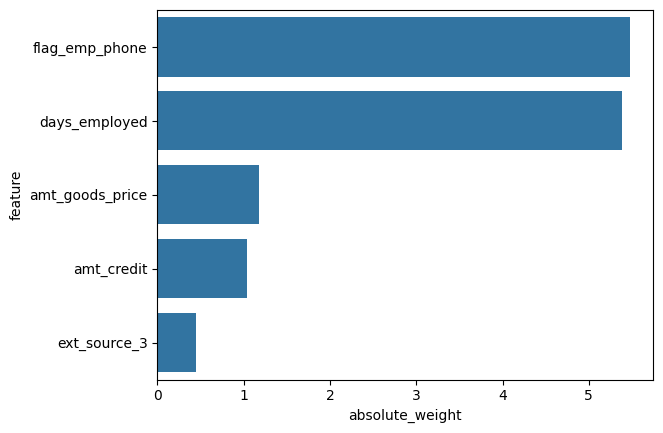

In [89]:
# ваш график
import matplotlib.pyplot as plt
import seaborn as sns

sns.barplot(data=features_weight.head(n=top_k), y='feature', x='absolute_weight')

(*Описание наибольших по модулю веса признаков см. ниже*)

Выведите топ признаков с наибольшим/наименьшим абсолютным весом.<br>
Опишите наблюдения (ответьте на вопрос: правда ли, что если признак `X` больше/меньше, то вероятность дефолта клиента выше/ниже?).

In [85]:
# вывод топ фичей
features_weight.head(n=top_k)

,feature,weight,absolute_weight
0,flag_emp_phone,5.475024,5.475024
1,days_employed,5.382772,5.382772
2,amt_goods_price,-1.174259,1.174259
3,amt_credit,1.043074,1.043074
4,ext_source_3,-0.451747,0.451747


In [87]:
features_weight.tail(n=top_k)

,feature,weight,absolute_weight
99,entrances_mode,-0.002736,0.002736
100,floorsmin_mode,0.001835,0.001835
101,flag_document_7,0.001817,0.001817
102,years_build_mode,-0.001583,0.001583
103,floorsmin_avg,-0.000271,0.000271


Топ признаков с наибольшим абсолютным весом:
1. FLAG_EMP_PHONE - Предоставил ли клиент рабочий телефон (1=ДА, 0=НЕТ)
2. DAYS_EMPLOYED - За солько дней до подачи заявления данное лицо приступило к текущей трудовой деятельности?
3. AMT_GOODS_PRICE - Цена товара, на который выдаётся кредит (для потребительских кредитов)
4. AMT_CREDIT - Сумма кредита
5. EXT_SOURCE_3 - Оценка из внешнего источника данных (нормализованная)

Топ признаков с наименьшим абсолютным весом:
1. ENTRANCES_MODE - Информация о здании, в котором проживает клиент: количество подъездов (мода)
2. FLOORSMIN_MODE - Информация о здании, в котором проживает клиент: номер этажа (мода)
3. FLAG_DOCUMENT_7 - Предоставил ли клиент документ 7?
4. YEARS_BUILD_MODE - Информация о здании, в котором проживает клиент: возраст здания (мода)
5. FLOORSMIN_AVG - Информация о здании, в котором проживает клиент: номер этажа (среднее)

**Выводы:**
Так как плохой заёмщик=-1, а хороший заёмщик=1, то
- если признак X БОЛЬШОЙ и соответствующий коэффициент ПОЛОЖИТЕЛЬНЫЙ, то вероятность дефолта НИЖЕ
- если признак X БОЛЬШОЙ и соответствующий коэффициент ОТРИЦАТЕЛЬНЫЙ, то вероятность дефолта ВЫШЕ

Значит ответ на вопрос - не всегда, зависит от знака соответствующего коэффициента